In [88]:
import pandas as pd
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.pyplot as plt
from tabulate import tabulate

In [35]:
inflow = pd.read_csv("countyinflow2122.csv", encoding="latin1")
outflow = pd.read_csv("countyoutflow2122.csv", encoding="latin1")

In [36]:
print(outflow.columns)

Index(['y1_statefips', 'y1_countyfips', 'y2_statefips', 'y2_countyfips',
       'y2_state', 'y2_countyname', 'n1', 'n2', 'agi'],
      dtype='object')


In [37]:
print(inflow.columns)

Index(['y2_statefips', 'y2_countyfips', 'y1_statefips', 'y1_countyfips',
       'y1_state', 'y1_countyname', 'n1', 'n2', 'agi'],
      dtype='object')


In [38]:
outflow = outflow[outflow["y1_statefips"] == 6]

In [39]:
inflow = inflow[inflow["y2_statefips"] == 6]

In [40]:
print(outflow["y2_countyname"].head(10))

4630     Alameda County Total Migration-US and Foreign
4631                 Alameda County Total Migration-US
4632         Alameda County Total Migration-Same State
4633    Alameda County Total Migration-Different State
4634            Alameda County Total Migration-Foreign
4635                       Alameda County Non-migrants
4636                               Contra Costa County
4637                                Santa Clara County
4638                                San Joaquin County
4639                              San Francisco County
Name: y2_countyname, dtype: object


In [41]:
#inflow.to_csv("reduced_inflow.csv", index=False)
#outflow.to_csv("reduced_outflow.csv", index=False)

In [42]:
inflow = inflow[inflow["y1_countyname"].str.contains("Total Migration-US and Foreign", regex=True, na=False)]
outflow = outflow[outflow["y2_countyname"].str.contains("Total Migration-US and Foreign", regex=True, na=False)]

In [43]:
print(inflow["y1_countyname"].head(10))

4777        Alameda County Total Migration-US and Foreign
4958         Alpine County Total Migration-US and Foreign
4968         Amador County Total Migration-US and Foreign
4991          Butte County Total Migration-US and Foreign
5047      Calaveras County Total Migration-US and Foreign
5072         Colusa County Total Migration-US and Foreign
5089    Contra Costa County Total Migration-US and For...
5191      Del Norte County Total Migration-US and Foreign
5206      El Dorado County Total Migration-US and Foreign
5256         Fresno County Total Migration-US and Foreign
Name: y1_countyname, dtype: object


In [44]:
inflow = inflow.drop(columns=["y2_statefips", "y2_countyfips", "y1_statefips", "y1_countyfips", "y1_state"])
inflow = inflow.rename(columns={
    "y1_countyname": "county_name",
    "n2": "individuals_inflow",
    "n1": "tax_returns_inflow",
    "agi": "agi_inflow",
})

In [45]:
outflow = outflow.drop(columns=["y2_statefips", "y2_countyfips", "y1_statefips", "y1_countyfips", "y2_state"])
outflow = outflow.rename(columns={
    "y2_countyname": "county_name",
    "n2": "individuals_outflow",
    "n1": "tax_returns_outflow",
    "agi": "agi_outflow",
})

In [48]:
inflow.to_csv("inflow_total.csv", index=False)
outflow.to_csv("outflow_total.csv", index=False)

In [49]:
net_migration = inflow.merge(outflow, on = ["county_name"], how = "outer")

In [50]:
print(net_migration.head(10))

                                         county_name  tax_returns_inflow  \
0      Alameda County Total Migration-US and Foreign               43682   
1       Alpine County Total Migration-US and Foreign                  21   
2       Amador County Total Migration-US and Foreign                1480   
3        Butte County Total Migration-US and Foreign                4726   
4    Calaveras County Total Migration-US and Foreign                1647   
5       Colusa County Total Migration-US and Foreign                 377   
6  Contra Costa County Total Migration-US and For...               27074   
7    Del Norte County Total Migration-US and Foreign                 556   
8    El Dorado County Total Migration-US and Foreign                6182   
9       Fresno County Total Migration-US and Foreign               12395   

   individuals_inflow  agi_inflow  tax_returns_outflow  individuals_outflow  \
0               68080     6230712                55667                94920   
1    

In [51]:
net_migration["individuals_flow_net"] = net_migration["individuals_inflow"] - net_migration["individuals_outflow"]
net_migration["tax_returns_flow_net"] = net_migration["tax_returns_inflow"] - net_migration["tax_returns_outflow"]
net_migration["agi_flow_net"] = net_migration["agi_inflow"] - net_migration["agi_outflow"]

In [52]:
print(net_migration.head(10))

                                         county_name  tax_returns_inflow  \
0      Alameda County Total Migration-US and Foreign               43682   
1       Alpine County Total Migration-US and Foreign                  21   
2       Amador County Total Migration-US and Foreign                1480   
3        Butte County Total Migration-US and Foreign                4726   
4    Calaveras County Total Migration-US and Foreign                1647   
5       Colusa County Total Migration-US and Foreign                 377   
6  Contra Costa County Total Migration-US and For...               27074   
7    Del Norte County Total Migration-US and Foreign                 556   
8    El Dorado County Total Migration-US and Foreign                6182   
9       Fresno County Total Migration-US and Foreign               12395   

   individuals_inflow  agi_inflow  tax_returns_outflow  individuals_outflow  \
0               68080     6230712                55667                94920   
1    

In [53]:
print(net_migration[net_migration["county_name"].str.contains("Riverside", regex=True, na=False)])

                                        county_name  tax_returns_inflow  \
32  Riverside County Total Migration-US and Foreign               60407   

    individuals_inflow  agi_inflow  tax_returns_outflow  individuals_outflow  \
32              113590     4873967                57357               104167   

    agi_outflow  individuals_flow_net  tax_returns_flow_net  agi_flow_net  
32      4237112                  9423                  3050        636855  


In [54]:
net_migration["county_name"] = net_migration["county_name"].str.replace(
    r"\s*County Total Migration-US and Foreign$", 
    "", 
    regex=True
)

In [55]:
print(net_migration.head(10))

    county_name  tax_returns_inflow  individuals_inflow  agi_inflow  \
0       Alameda               43682               68080     6230712   
1        Alpine                  21                  33        1957   
2        Amador                1480                2530      121740   
3         Butte                4726                7849      275031   
4     Calaveras                1647                3082      154735   
5        Colusa                 377                 725       23839   
6  Contra Costa               27074               48153     4406137   
7     Del Norte                 556                 934       32003   
8     El Dorado                6182               11018      747175   
9        Fresno               12395               22123      734241   

   tax_returns_outflow  individuals_outflow  agi_outflow  \
0                55667                94920      8693754   
1                   58                   89         7187   
2                 1159                

## Mapping Counties

In [67]:
# 1. Read US counties shapefile directly from Census (2023, 1:500k)
url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
counties = gpd.read_file(url)

# 2. Filter to California (STATEFP '06')
ca = counties[counties["STATEFP"] == "06"].copy()

#print(ca[["NAME", "GEOID"]].head())
ca = ca.rename(columns={"NAME": "county_name"})

ca_merged = ca.merge(net_migration, on="county_name", how = "left")
#print(ca_merged.head(10))
#print(ca_merged.columns)
print(len(ca["county_name"].unique()))
ca_merged["net_individuals_100k"] = ca_merged["individuals_flow_net"] / 100000


58


In [76]:
colors = ["#8b0000", "white","#006400"]  
custom_cmap = LinearSegmentedColormap.from_list("green_white_red", colors)

In [93]:
# after you create ca_merged["net_agi_millions"]
vmin = ca_merged["net_individuals_100k"].min()
vmax = ca_merged["net_individuals_100k"].max()

# Make symmetric limits around 0
limit = max(abs(vmin), abs(vmax))    # ≈ 25.041008

norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

In [94]:
ascending_individuals = ca_merged.sort_values("net_individuals_100k", ascending = True)
#print(ascending_individuals[["net_individuals_100k","county_name"]].head(10))
table = tabulate(ascending_individuals[["county_name", "net_individuals_100k"]], headers="keys", tablefmt="pretty")

print(table)

+----+-----------------+----------------------+
|    |   county_name   | net_individuals_100k |
+----+-----------------+----------------------+
| 0  |   Los Angeles   |       -1.17458       |
| 32 |   Santa Clara   |       -0.33118       |
| 49 |     Orange      |       -0.29831       |
| 12 |    San Diego    |       -0.26865       |
| 28 |     Alameda     |       -0.2684        |
| 57 |  San Francisco  |       -0.13558       |
| 18 |   Sacramento    |       -0.11865       |
| 15 |    San Mateo    |       -0.11615       |
| 3  |  Contra Costa   |       -0.07534       |
| 38 |     Ventura     |       -0.05728       |
| 47 |  Santa Barbara  |       -0.04786       |
| 30 |    Monterey     |       -0.04547       |
| 27 | San Bernardino  |       -0.04537       |
| 37 |     Fresno      |       -0.03664       |
| 1  |   Santa Cruz    |       -0.02979       |
| 53 |      Kern       |       -0.02454       |
| 25 |   Stanislaus    |       -0.02403       |
| 14 |      Marin      |       -0.02368 

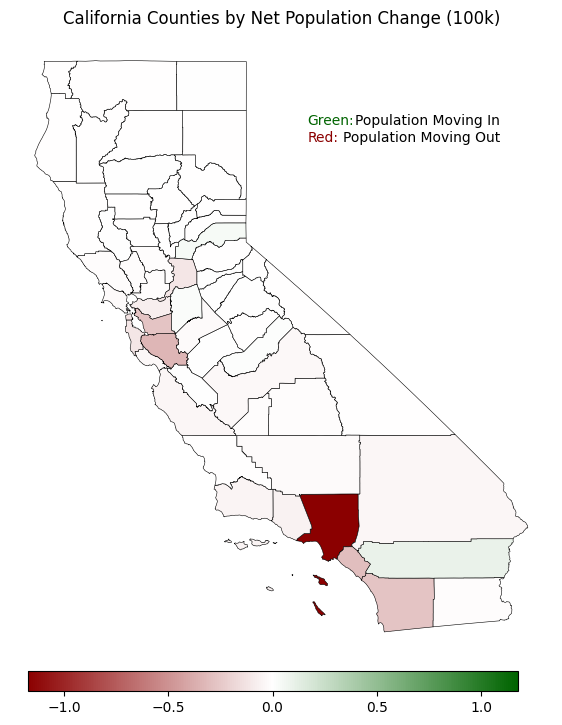

In [95]:
fig, ax = plt.subplots(figsize=(7, 10))


ca_merged.plot(
    column="net_individuals_100k",
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    ax=ax,
    missing_kwds={"color": "lightgray", "label": "Missing Data"}
)
"""
ca_merged.plot(
    column="net_agi_millions",
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    #legend=True,
    ax=ax,
    
    # ⬅️ NEW: style NaN counties in gray
    missing_kwds={
        "color": "lightgray",   # fill color for missing data
        #"edgecolor": "black",
        #"hatch": "///",
        "label": "Missing Data"
    }
) 
"""   
"""
plt.figtext(
    0.55, 0.717,                     # position (centered, slightly below the figure)
    "Gray:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "gray"
)
"""

plt.figtext(
    0.55, 0.683,                     # position (centered, slightly below the figure)
    "Red:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "#8b0000"
)

plt.figtext(
    0.55, 0.7,                     # position (centered, slightly below the figure)
    "Green:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "#006400"
)
"""
plt.figtext(
    0.8, 0.7,                     # position (centered, slightly below the figure)
    "Missing Data\nDecreasing Price\nIncreasing Price",         # caption text
    ha="right", fontsize=10
)
"""

"""
plt.figtext(
    0.8, 0.717,                     # position (centered, slightly below the figure)
    "Missing Data\n",#Green:\nRed",         # caption text
    ha="right", fontsize=10
)
"""

plt.figtext(
    0.825, 0.683,                     # position (centered, slightly below the figure)
    "Population Moving Out\n",            # caption text
    ha="right", fontsize=10
)

plt.figtext(
    0.825, 0.7,                     # position (centered, slightly below the figure)
    "Population Moving In\n",          # caption text
    ha="right", fontsize=10
)

# ---- Shrink colorbar size ----
# Create a custom axis (x0, y0, width, height) in figure coordinates
cax = fig.add_axes([0.15, 0.15, 0.7, 0.02])  # adjust width & height

# Draw the colorbar into the smaller axis
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation="horizontal")

ax.set_axis_off()
ax.set_title("California Counties by Net Population Change (100k)", fontsize=12)
plt.show()

In [97]:
print(ca_merged[["county_name","agi_flow_net"]])

        county_name  agi_flow_net
0       Los Angeles      -6266562
1        Santa Cruz        -55641
2            Sonoma         -2795
3      Contra Costa       -530087
4            Alpine         -5230
5            Nevada         34037
6             Butte        -25502
7            Shasta          4608
8            Merced          2332
9         Calaveras         31828
10             Lake         -7809
11             Yuba         22047
12        San Diego       -420548
13        Riverside        636855
14            Marin        205692
15        San Mateo      -2624489
16        El Dorado         59562
17           Tulare        -86369
18       Sacramento       -285548
19       San Benito         61855
20           Amador         51628
21           Sutter        -33149
22             Yolo        -78555
23           Colusa         -1039
24           Plumas        -13207
25       Stanislaus       -175343
26          Trinity         -1743
27   San Bernardino       -428957
28          Al